In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

spx = pd.read_csv("../data/spx.csv", index_col=0, parse_dates=True)
realized_vol = pd.read_csv("../data/realized_volatility.csv", index_col=0, parse_dates=True)
garch_forecasts = pd.read_csv("../data/garch_forecasts.csv", index_col=0, parse_dates=True)
cv_splits = pd.read_csv("../data/cv_splits.csv", parse_dates=["train_start", "train_end", "test_start", "test_end"])

spx_returns = np.log(spx["Close"] / spx["Close"].shift(1))

print(f"SPX prices: {len(spx)} rows")
print(f"Realized vol: {len(realized_vol)} rows")
print(f"GARCH forecasts: {len(garch_forecasts)} rows")
print(f"CV splits: {len(cv_splits)} rows")

SPX prices: 2012 rows
Realized vol: 1992 rows
GARCH forecasts: 2669 rows
CV splits: 84 rows


In [7]:
def build_features(prices, returns, realized_vol_series):
    df = pd.DataFrame(index=prices.index)
    
    # Lagged realized vol (uses the target itself, lagged, as a predictor)
    for lag in [1, 5, 10, 21]:
        df[f"vol_lag_{lag}"] = realized_vol_series.shift(lag)
    
    # Lagged squared returns (GARCH's own ARCH term, as an ML feature)
    squared_returns = returns ** 2
    for lag in [1, 5, 10, 21]:
        df[f"sq_return_lag_{lag}"] = squared_returns.shift(lag)
    
    # Rolling volume (21-day average, shifted by 1 so "today's" volume isn't used to predict "today")
    df["rolling_volume"] = prices["Volume"].rolling(21).mean().shift(1)
    
    # Leverage effect proxy: sign of the return 1 day ago
    df["return_sign_lag1"] = np.sign(returns.shift(1))
    
    return df

spx_features = build_features(spx, spx_returns, realized_vol["spx"])
print(f"Feature columns: {list(spx_features.columns)}")
print(f"Shape: {spx_features.shape}")
spx_features.head(25)

Feature columns: ['vol_lag_1', 'vol_lag_5', 'vol_lag_10', 'vol_lag_21', 'sq_return_lag_1', 'sq_return_lag_5', 'sq_return_lag_10', 'sq_return_lag_21', 'rolling_volume', 'return_sign_lag1']
Shape: (2012, 10)


,vol_lag_1,vol_lag_5,vol_lag_10,vol_lag_21,sq_return_lag_1,sq_return_lag_5,sq_return_lag_10,sq_return_lag_21,rolling_volume,return_sign_lag1
Date,,,,,,,,,,
2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-05,NaN,NaN,NaN,NaN,3.255802e-05,NaN,NaN,NaN,NaN,1.0
2017-01-06,NaN,NaN,NaN,NaN,5.943910e-07,NaN,NaN,NaN,NaN,-1.0
2017-01-09,NaN,NaN,NaN,NaN,1.232564e-05,NaN,NaN,NaN,NaN,1.0
2017-01-10,NaN,NaN,NaN,NaN,1.263735e-05,NaN,NaN,NaN,NaN,-1.0
2017-01-11,NaN,NaN,NaN,NaN,0.000000e+00,3.255802e-05,NaN,NaN,NaN,0.0
2017-01-12,NaN,NaN,NaN,NaN,7.984255e-06,5.943910e-07,NaN,NaN,NaN,1.0
2017-01-13,NaN,NaN,NaN,NaN,4.610092e-06,1.232564e-05,NaN,NaN,NaN,-1.0


In [8]:
spx_data = spx_features.copy()
spx_data["target"] = realized_vol["spx"]
spx_data = spx_data.dropna()

print(f"Final dataset shape: {spx_data.shape}")
print(f"Date range: {spx_data.index.min()} to {spx_data.index.max()}")
spx_data.head()

Final dataset shape: (1971, 11)
Date range: 2017-03-03 00:00:00 to 2024-12-31 00:00:00


,vol_lag_1,vol_lag_5,vol_lag_10,vol_lag_21,sq_return_lag_1,sq_return_lag_5,sq_return_lag_10,sq_return_lag_21,rolling_volume,return_sign_lag1,target
Date,,,,,,,,,,,
2017-03-03,4.971740,5.056819,5.487603,6.177712,3.454050e-05,0.000002,7.473457e-07,8.899422e-08,3.687267e+09,-1.0,4.748900
2017-03-06,4.748900,5.088689,5.353912,5.997679,2.537644e-07,0.000001,2.812830e-06,3.250674e-07,3.670004e+09,1.0,4.711501
2017-03-07,4.711501,5.120947,5.254157,5.983690,1.077561e-05,0.000007,3.635909e-05,5.239584e-05,3.643434e+09,-1.0,4.753186
2017-03-08,4.753186,5.024606,5.058513,5.917677,8.512541e-06,0.000184,1.172426e-06,4.484219e-06,3.639640e+09,-1.0,4.809801
2017-03-09,4.809801,4.971740,4.994064,5.696460,5.229582e-06,0.000035,1.754763e-07,5.143981e-08,3.673054e+09,-1.0,4.948554


In [10]:
feature_cols = [col for col in spx_data.columns if col != "target"]

split_check = []
for idx, row in cv_splits.iterrows():
    train_mask = (spx_data.index >= row["train_start"]) & (spx_data.index <= row["train_end"])
    test_mask = (spx_data.index >= row["test_start"]) & (spx_data.index <= row["test_end"])
    
    n_train = train_mask.sum()
    n_test = test_mask.sum()
    
    split_check.append({"split": idx, "n_train": n_train, "n_test": n_test})

split_check_df = pd.DataFrame(split_check)
print(split_check_df.head(10))
print(f"\nAny splits with 0 train rows? {(split_check_df['n_train'] == 0).any()}")
print(f"Any splits with 0 test rows? {(split_check_df['n_test'] == 0).any()}")

   split  n_train  n_test
0      0      212      21
1      1      233      21
2      2      254      21
3      3      275      21
4      4      296      21
5      5      317      21
6      6      338      21
7      7      359      21
8      8      380      21
9      9      401      21

Any splits with 0 train rows? False
Any splits with 0 test rows? False


In [11]:
print(split_check_df.tail(10))

    split  n_train  n_test
74     74     1766      21
75     75     1787      21
76     76     1808      21
77     77     1829      21
78     78     1850      21
79     79     1871      21
80     80     1892      21
81     81     1913      21
82     82     1934      21
83     83     1955      16


In [12]:
def train_quantile_models(train_X, train_y):
    models = {}
    for alpha in [0.1, 0.5, 0.9]:
        model = lgb.LGBMRegressor(
            objective="quantile",
            alpha=alpha,
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            verbose=-1
        )
        model.fit(train_X, train_y)
        models[alpha] = model
    return models

all_predictions = []

for idx, row in cv_splits.iterrows():
    train_mask = (spx_data.index >= row["train_start"]) & (spx_data.index <= row["train_end"])
    test_mask = (spx_data.index >= row["test_start"]) & (spx_data.index <= row["test_end"])
    
    train_X = spx_data.loc[train_mask, feature_cols]
    train_y = spx_data.loc[train_mask, "target"]
    test_X = spx_data.loc[test_mask, feature_cols]
    test_dates = spx_data.loc[test_mask].index
    
    if len(train_X) < 30:  # skip splits with too little data to train meaningfully
        continue
    
    models = train_quantile_models(train_X, train_y)
    
    for date, x_row in zip(test_dates, test_X.values):
        x_row_2d = x_row.reshape(1, -1)
        pred_low = models[0.1].predict(x_row_2d)[0]
        pred_mid = models[0.5].predict(x_row_2d)[0]
        pred_high = models[0.9].predict(x_row_2d)[0]
        all_predictions.append({"date": date, "pred_low": pred_low, "pred_mid": pred_mid, "pred_high": pred_high})

print(f"Total predictions generated: {len(all_predictions)}")

c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: 

Total predictions generated: 1759


c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Volatility-forecasting-with-GARCH-vs.-ML-models\venv\Lib\site-packages\sklearn\utils\validation.py:2827: 

In [13]:
predictions_df = pd.DataFrame(all_predictions).set_index("date")
print(f"Shape: {predictions_df.shape}")
predictions_df.head()

Shape: (1759, 3)


,pred_low,pred_mid,pred_high
date,,,
2018-01-04,4.389255,4.691490,5.094875
2018-01-05,4.219063,4.145315,5.015341
2018-01-08,3.610184,3.767704,5.101366
2018-01-09,3.602573,3.747875,5.048270
2018-01-10,3.593229,3.712605,5.023070


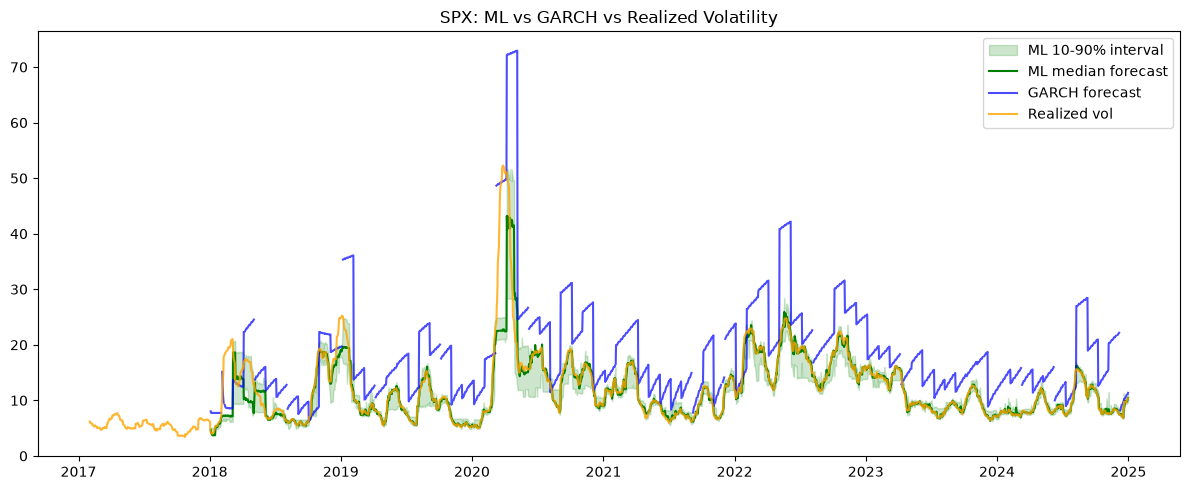

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(predictions_df.index, predictions_df["pred_low"], predictions_df["pred_high"], 
                 alpha=0.2, color="green", label="ML 10-90% interval")
ax.plot(predictions_df.index, predictions_df["pred_mid"], color="green", label="ML median forecast")
ax.plot(garch_forecasts.index, garch_forecasts["spx"], color="blue", alpha=0.7, label="GARCH forecast")
ax.plot(realized_vol.index, realized_vol["spx"], color="orange", alpha=0.8, label="Realized vol")

ax.set_title("SPX: ML vs GARCH vs Realized Volatility")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
def rmse(pred, actual):
    aligned = pd.concat([pred, actual], axis=1, join="inner").dropna()
    aligned.columns = ["pred", "actual"]
    return np.sqrt(((aligned["pred"] - aligned["actual"]) ** 2).mean())

ml_rmse = rmse(predictions_df["pred_mid"], realized_vol["spx"])
garch_rmse = rmse(garch_forecasts["spx"], realized_vol["spx"])

print(f"ML median RMSE: {ml_rmse:.2f}")
print(f"GARCH RMSE: {garch_rmse:.2f}")

# Calibration check: what % of actual values fall inside the 10-90% predicted interval?
merged_check = pd.concat([predictions_df, realized_vol["spx"]], axis=1, join="inner").dropna()
merged_check.columns = ["pred_low", "pred_mid", "pred_high", "actual"]

inside_interval = (merged_check["actual"] >= merged_check["pred_low"]) & (merged_check["actual"] <= merged_check["pred_high"])
coverage = inside_interval.mean() * 100

print(f"\n10-90% interval coverage: {coverage:.1f}% (target: ~80%)")

ML median RMSE: 3.20
GARCH RMSE: 8.59

10-90% interval coverage: 81.7% (target: ~80%)


In [16]:
# Refit one model on the full dataset just to extract feature importances cleanly
final_model = lgb.LGBMRegressor(objective="quantile", alpha=0.5, n_estimators=100, max_depth=4, learning_rate=0.05, verbose=-1)
final_model.fit(spx_data[feature_cols], spx_data["target"])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

vol_lag_1           590
vol_lag_5           127
vol_lag_10          101
sq_return_lag_21    100
rolling_volume       88
vol_lag_21           83
sq_return_lag_1      81
return_sign_lag1     47
sq_return_lag_5      39
sq_return_lag_10     33
dtype: int32


In [17]:
def run_ml_pipeline(prices, returns, realized_vol_series, cv_splits, asset_name):
    features = build_features(prices, returns, realized_vol_series)
    data = features.copy()
    data["target"] = realized_vol_series
    data = data.dropna()
    
    feature_cols = [col for col in data.columns if col != "target"]
    predictions = []
    
    for idx, row in cv_splits.iterrows():
        train_mask = (data.index >= row["train_start"]) & (data.index <= row["train_end"])
        test_mask = (data.index >= row["test_start"]) & (data.index <= row["test_end"])
        
        train_X = data.loc[train_mask, feature_cols]
        train_y = data.loc[train_mask, "target"]
        test_X = data.loc[test_mask, feature_cols]
        test_dates = data.loc[test_mask].index
        
        if len(train_X) < 30:
            continue
        
        models = train_quantile_models(train_X, train_y)
        
        for date, x_row in zip(test_dates, test_X.values):
            x_row_2d = pd.DataFrame([x_row], columns=feature_cols)  # fixes the earlier warning too
            pred_low = models[0.1].predict(x_row_2d)[0]
            pred_mid = models[0.5].predict(x_row_2d)[0]
            pred_high = models[0.9].predict(x_row_2d)[0]
            predictions.append({"date": date, "pred_low": pred_low, "pred_mid": pred_mid, "pred_high": pred_high})
    
    result = pd.DataFrame(predictions).set_index("date")
    print(f"{asset_name}: {len(result)} predictions generated")
    return result

In [18]:
stable = pd.read_csv("../data/stable.csv", index_col=0, parse_dates=True)
tech = pd.read_csv("../data/tech.csv", index_col=0, parse_dates=True)
btc = pd.read_csv("../data/btc.csv", index_col=0, parse_dates=True)

stable_returns = np.log(stable["Close"] / stable["Close"].shift(1))
tech_returns = np.log(tech["Close"] / tech["Close"].shift(1))
btc_returns = np.log(btc["Close"] / btc["Close"].shift(1))

stable_predictions = run_ml_pipeline(stable, stable_returns, realized_vol["stable"], cv_splits, "Stable")
tech_predictions = run_ml_pipeline(tech, tech_returns, realized_vol["tech"], cv_splits, "Tech")
btc_predictions = run_ml_pipeline(btc, btc_returns, realized_vol["btc"], cv_splits, "BTC")

Stable: 1759 predictions generated
Tech: 1759 predictions generated
BTC: 1759 predictions generated


In [19]:
for name, predictions, garch_col in [("Stable", stable_predictions, "stable"), 
                                        ("Tech", tech_predictions, "tech"), 
                                        ("BTC", btc_predictions, "btc")]:
    ml_rmse = rmse(predictions["pred_mid"], realized_vol[garch_col])
    garch_rmse = rmse(garch_forecasts[garch_col], realized_vol[garch_col])
    
    merged_check = pd.concat([predictions, realized_vol[garch_col]], axis=1, join="inner").dropna()
    merged_check.columns = ["pred_low", "pred_mid", "pred_high", "actual"]
    inside_interval = (merged_check["actual"] >= merged_check["pred_low"]) & (merged_check["actual"] <= merged_check["pred_high"])
    coverage = inside_interval.mean() * 100
    
    print(f"{name}: ML RMSE={ml_rmse:.2f}, GARCH RMSE={garch_rmse:.2f}, ML interval coverage={coverage:.1f}%")

Stable: ML RMSE=4.55, GARCH RMSE=5.28, ML interval coverage=81.6%
Tech: ML RMSE=3.91, GARCH RMSE=15.68, ML interval coverage=80.6%
BTC: ML RMSE=4.63, GARCH RMSE=21.92, ML interval coverage=82.0%


In [20]:
all_ml_forecasts = pd.DataFrame({
    "spx_low": predictions_df["pred_low"], "spx_mid": predictions_df["pred_mid"], "spx_high": predictions_df["pred_high"],
    "stable_low": stable_predictions["pred_low"], "stable_mid": stable_predictions["pred_mid"], "stable_high": stable_predictions["pred_high"],
    "tech_low": tech_predictions["pred_low"], "tech_mid": tech_predictions["pred_mid"], "tech_high": tech_predictions["pred_high"],
    "btc_low": btc_predictions["pred_low"], "btc_mid": btc_predictions["pred_mid"], "btc_high": btc_predictions["pred_high"],
})

all_ml_forecasts.to_csv("../data/ml_forecasts.csv")
print(f"Saved {len(all_ml_forecasts)} rows to ml_forecasts.csv")
all_ml_forecasts.head()

Saved 1759 rows to ml_forecasts.csv


,spx_low,spx_mid,spx_high,stable_low,stable_mid,stable_high,tech_low,tech_mid,tech_high,btc_low,btc_mid,btc_high
date,,,,,,,,,,,,
2018-01-04,4.389255,4.691490,5.094875,9.495054,9.965396,9.722640,25.250027,30.705320,31.262273,94.311655,125.364436,135.285876
2018-01-05,4.219063,4.145315,5.015341,9.618711,9.987920,9.798009,23.742592,25.796394,28.849467,93.747974,124.564212,135.362073
2018-01-08,3.610184,3.767704,5.101366,9.571075,10.004245,9.789298,21.709442,22.922467,27.709673,93.279950,123.491672,133.816177
2018-01-09,3.602573,3.747875,5.048270,9.219599,9.965231,10.559989,21.863412,23.186365,29.902645,74.191082,122.070983,133.787948
2018-01-10,3.593229,3.712605,5.023070,9.028436,9.934089,9.812690,21.737734,23.266375,29.902645,92.383509,124.471839,134.051792
